# ============================================================
# MOLEDO LASSO TEMPORAL CON ID y SUBBAGING
#Autor: Hernan Garcia
#Fecha: 1/05/2026
#Fecha Ajuste: 1/05/2026
# ============================================================

In [1]:
# ============================================================
# PASO 0 — LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

In [2]:
# -------------------------------------------------------
# 1. Cargar los datos
# -------------------------------------------------------
# Ruta de tu archivo CSV (ajústala a tu disco)

BASEFINALAGRUPADA = pd.read_csv(r'C:\Users\garci\OneDrive\Programacion\01.Data\BASEFINALAGRUPADA.csv',
                               sep=';',
                               engine='python'
                               )

In [3]:
# ============================================================
# PASO 1 — BASE
# ============================================================

df = BASEFINALAGRUPADA.copy()
df.columns = df.columns.str.strip()

In [4]:
# ============================================================
# PASO 2 — AJUSTE DE VARIABLES (LOG)
# ============================================================

cat_vars = [
    "NUMERO CONTRATO",
    "ESTADO CONTRATO",
    "TIPO DE CONTRATO",
    "MODALIDAD DE CONTRATACION",
    "JUSTIFICACION DEL CONTRATO",
    "NIT_NOMBRE_CONTRATANTE",
    "DEPARTAMENTO ENTIDAD CONTRATANTE",
    "SECTOR ECONOMICO ENTIDAD CONTRATANTE",
    "ID_NOMBRE_CONTRATISTA",
    "TIPO DE EMPRESA CONTRATISTA",
    "DEPARTAMENTO CONTRATISTA"
]

dummy_vars = [
    "MULTA",
    "OBLIGACIONES AMBIENTALES",
    "OBLIGACIONES POST CONSUMO",
    "OBLIGACIONES POSCONFLICTO",
    "DESTINO GASTO",
    "ORDEN ENTIDAD",
    "AÑO DE ELECCIONES",
    "ELECCIONES PRESIDENCIALES",
    "ELECCIONES DE CONGRESO",
    "ELECCIONES MUNICIPALES"
]

cont_vars = [
    "AÑO FIRMA CONTRATO",
    "AÑO INICIO CONTRATO",
    "AÑO FINAL DEL CONTRATO",
    "SECUESTROS",
    "FINANCIERA",
    "POBLACION EN REINCORPORACION ELN",
    "POBLACION EN REINCORPORACION FARC",
    "POBLACION EN REINCORPORACION PARAMILITARES",
    "POBLACION EN REINCORPORACION OTROS",
    "COMBATE Y/O CONTACTO ARMADO FARC",
    "COMBATE Y/O CONTACTO ARMADO ELN",
    "COMBATE Y/O CONTACTO ARMADO PARAMILITAR",
    "COMBATE Y/O CONTACTO ARMADO OTROS",
    "POBLACION NINI",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMPETENCIAS CIUDADANAS",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMUNICACION ESCRITA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO ESCRITURA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO INLGES",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO LECTURA CRITICA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO RAZONAMIENTO CUANTITATIVO",
    "DELITOS ELECTORALES",
    "NRO CORRESPONSALES PROPIOS",
    "NRO CORRESPONSALES TERCERIZADOS",
    "NRO CORRESPONSALES ACTIVOS",
    "NRO CORRESPONSALES",
    "NRO GIROS ENVIADOS ",
    "MONTO GIROS ENVIADOS ",
    "NRO GIROS RECIBIDOS",
    "NRO PAGOS",
    "NRO RETIROS",
    "NRO TRANSFERENCIAS",
    "NRO TOTAL ",
    "NRO CTA AHORRO HASTA 1 SMMLV",
    "NRO CTA AHORRO > 1 SMMLV HASTA 3 SMMLV",
    "NRO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "NRO CTA AHORRO ACTIVAS",
    "NRO CTA AHORRO MUJERES",
    "NRO CTA AHORRO HOMBRES",
    "NRO TOTAL CTA AHORROS",
    "NRO CTA AHORRO ELECTRONICAS ACTIVAS",
    "NRO CTA AHORRO ELECTRONICAS MUJERES",
    "NRO CTA AHORRO ELECTRONICAS HOMBRES",
    "NRO TOTAL CTA AHORROS ELECTRONICAS ",
    "NRO CREDITO CONSUMO MUJERES",
    "MONTO CREDITO CONSUMO MUJERES",
    "NRO CREDITO CONSUMO HOMBRES",
    "MONTO CREDITO CONSUMO  HOMBRES",
    "NRO TOTAL CREDITO CONSUMO",
    "MONTO TOTAL CREDITO CONSUMO",
    "NRO CRED CONS BAJO MONTO MUJERES",
    "NRO CRED CONS BAJO MONTO HOMBRES",
    "NRO TOTAL CRED CONS BAJO MONTO",
    "NRO CREDITO VIVIENDA MUJERES",
    "MONTO CREDITO VIVIENDA MUJERES",
    "NRO CREDITO VIVIENDA HOMBRES",
    "MONTO CREDITO VIVIENDA HOMBRES",
    "NRO TOTAL CREDITO VIVIENDA",
    "NRO MICROCREDITO HASTA 1 SMMLV",
    "MONTO MICROCREDITO HASTA 1 SMMLV",
    "NRO MICROCREDITO > 1 SMMLV HASTA 2 SMMLV",
    "NRO MICROCREDITO> 2 SMMLV HASTA 3 SMMLV",
    "NRO MICROCREDITO> 3 SMMLV HASTA 4 SMMLV",
    "NRO MICROCREDITO> 4 SMMLV HASTA 10 SMMLV",
    "NRO MICROCREDITO> 10SMMLV HASTA 25SMMLV",
    "NRO MICROCREDITO MUJERES",
    "NRO MICROCREDITO HOMBRES",
    "NRO TOTAL MICROCREDITO ",
    "NRO PROD DEPOSITO NIVEL NACIONAL",
    "MONTO PROD DEPOSITO NIVEL NACIONAL"
    
]

index_vars = [
    "IDH",
    "PROMEDIO INDICE IICA",
    "TASA DE ALFABETIZACION",
    "INDICE EFICIENCIA FISCAL",
    "INDICE EFICACIA TOTAL ",
    "INDICE EFICIENCIA TOTAL",
    "INDICE REQUISITOS LEGALES",
    "CAPACIDAD ADMINISTRATIVA"
]

log_vars = [
    "VALOR CONTRATO",
    "PIB AGRICULTURA Y GANADERÍA",
    "PIB EXPLOTACIÓN DE MINAS Y CANTERAS",
    "PIB INDUSTRIAS MANUFACTURERAS",
    "PIB SUMINISTRO DE ELECTRICIDAD, GAS ETC",
    "PIB CONSTRUCCION",
    "PIB COMERCIO AL POR MAYOR Y AL POR MENOR",
    "PIB INFORMACIÓN Y COMUNICACIONES",
    "PIB ACTIVIDADES FINANCIERAS",
    "PIB ACTIVIDADES INMOBILIARIAS",
    "PIB ACTIVIDADES PROFESIONALES",
    "PIB ADMINISTRACIÓN PÚBLICA Y DEFENSA",
    "PIB ACTIVIDADES ARTÍSTICAS",
    "HOMICIDIOS",
    "HURTOS PERSONAS",
    "VIOLENCIA INTRAFAMILIAR",
    "HURTO A VEHICULOS",
    "DELITOS SEXUALES",
    "DELITOS MEDIO AMBIENTE",
    "HURTO A COMERCIOS",
    "RESIDENCIAS",
    "INCAUTACIONES DE ARMAS",
    "DESPLAZADOS PERCAPITA",
    "DESPLAZADOS NUMERO DE CASOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PUBLICA",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PRIVADA",
    "NUMERO DE MATRICULADOS A EDUCACION SUPERIOR",
    "NUMERO DE ADMITIDOS A EDUCACION SUPERIOR",
    "NUMERO DE INSCRITOS EN UNIVERSIDADES",
    "NUMERO EMPLEADOS ADMINISTRATIVOS",
    "NUMERO DE GRADUADOS",
    "HECTAREAS SEMBRADAS DE COCAINA",
    "DESMANTELAMIENTO DE LABORATORIOS",
    "HECTAREAS ERRADICADAS",
    "ENCAUTACIONES DE DROGA EN GRAMOS",
    "NRO DEPOSITOS",
    "MONTO DEPOSITOS",
    "MONTO GIROS RECIBIDOS",
    "MONTO PAGOS",
    "MONTO RETIROS",
    "MONTO TRANSFERENCIAS",
    "MONTO TOTAL",
    "SALDO CTA AHORRO HASTA 1 SMMLV",
    "SALDO CTA AHORRO> 1 SMMLV HASTA 3 SMMLV",
    "SALDO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "SALDO CTA AHORRO ACTIVAS",
    "SALDO CTA AHORRO MUJERES",
    "SALDO CTA AHORRO HOMBRES",
    "SALDO TOTAL CTA AHORROS",
    "SALDO CTA AHORRO ELECTRONICAS ACTIVAS",
    "SALDO CTA AHORRO ELECTRONICAS MUJERES",
    "SALDO CTA AHORRO ELECTRONICAS HOMBRES",
    "SALDO TOTAL CTA AHORROS ELECTRONICAS ",
    "MONTO CRED CONS BAJO MONTO MUJERES",
    "MONTO CRED CONS BAJO MONTO HOMBRES",
    "MONTO TOTAL CRED CONS BAJO MONTO",
    "MONTO TOTAL CREDITO VIVIENDA",
    "MONTO MICROCREDITO> 1SMMLV HASTA 2SMMLV",
    "MONTO MICROCREDITO> 2SMMLV HASTA 3SMMLV",
    "MONTO MICROCREDITO> 3SMMLV HASTA 4SMMLV",
    "MONTO MICROCREDITO> 4SMMLV HASTA 10SMML",
    "MONTO MICROCREDI> 10SMMLV HASTA 25SMMLV",
    "MONTO MICROCREDITO MUJERES",
    "MONTO MICROCREDITO HOMBRES",
    "MONTO TOTAL MICROCREDITO"
    
]

# --- LOG ---
for col in log_vars:
    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(" ", "", regex=False)
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0)
        df[col] = np.log1p(df[col])


# --- CONTINUAS ---
for col in cont_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# --- DUMMIES ---
for col in dummy_vars:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        df[col] = df[col].astype(int)


# --- CATEGÓRICAS ---
for col in cat_vars:
    if col in df.columns:
        df[col] = df[col].astype(str)


# --- ÍNDICES ---
for col in index_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [5]:
# ============================================================
# PASO 2 — VARIABLES CLAVE
# ============================================================

target_var = "MULTA"
year_var = "AÑO FIRMA CONTRATO"

In [6]:
# ============================================================
# PASO 4 — PLAZO
# ============================================================

if "AÑO INICIO CONTRATO" in df.columns and "AÑO FINAL DEL CONTRATO" in df.columns:

    plazo = (
        df["AÑO FINAL DEL CONTRATO"] - df["AÑO INICIO CONTRATO"]
    ).clip(lower=0)

    df = df.assign(PLAZO_CONTRATO=plazo)

    df = df.drop(columns=[
        "AÑO INICIO CONTRATO",
        "AÑO FINAL DEL CONTRATO"
    ])

# 🔥 DESFRAGMENTAR (CLAVE)
df = df.copy()

In [7]:
# ============================================================
# PASO 5 — SPLIT TEMPORAL
# ============================================================

cut_year = 2020

train_df = df[df[year_var] < cut_year]
test_df  = df[df[year_var] >= cut_year]

In [8]:
# ============================================================
# PASO 6 — X / y
# ============================================================

X_train = train_df.drop(columns=[target_var])
y_train = train_df[target_var]

X_test = test_df.drop(columns=[target_var])
y_test = test_df[target_var]

X_train = X_train.drop(columns=[year_var], errors="ignore")
X_test  = X_test.drop(columns=[year_var], errors="ignore")


In [9]:
# ============================================================
# PASO 7 — ELIMINAR COLUMNAS VACÍAS
# ============================================================

cols_all_nan = X_train.columns[X_train.isna().all()]

X_train = X_train.drop(columns=cols_all_nan)
X_test  = X_test.drop(columns=cols_all_nan)

In [10]:
# ============================================================
# PASO 8 — DEFINIR COLUMNAS
# ============================================================

categorical_cols = [col for col in cat_vars if col in X_train.columns]
numeric_cols = [
    col for col in (cont_vars + log_vars + index_vars + dummy_vars)
    if col in X_train.columns
]


In [11]:
# ============================================================
# PASO 9 — REDUCIR CARDINALIDAD
# ============================================================

for col in categorical_cols:

    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    top = X_train[col].value_counts().nlargest(10).index

    X_train[col] = X_train[col].where(X_train[col].isin(top), "OTROS")
    X_test[col] = X_test[col].where(X_test[col].isin(top), "OTROS")

In [17]:
# ============================================================
# PASO 10 — PREPROCESAMIENTO
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), categorical_cols),

    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())  # 🔥 clave para LASSO
    ]), numeric_cols)

], sparse_threshold=1.0)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

In [18]:
# ============================================================
# PASO 11 — MODELO LASSO
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 50]  # 🔥 rango corregido
}

lasso = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,        # 🔥 más iteraciones
    tol=1e-2,             # 🔥 relajado
    class_weight="balanced",
    n_jobs=-1,
    warm_start=True       # 🔥 acelera convergencia
)

grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1
)

grid.fit(X_train_enc, y_train)

best_model = grid.best_estimator_

print("\nMejor C:", grid.best_params_["C"])
print("Lambda:", 1 / grid.best_params_["C"])
print("Mejor AUC:", grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Mejor C: 0.01
Lambda: 100.0
Mejor AUC: 0.9624989570610074


In [19]:
# ============================================================
# PASO 12 — PROBABILIDADES
# ============================================================

test_probs = best_model.predict_proba(X_test_enc)[:, 1]

In [20]:
# ============================================================
# PASO 13 — THRESHOLD ROBUSTO
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.001, 0.2, 50)

results = []

for t in thresholds:

    y_pred_temp = (test_probs > t).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(
    results,
    columns=["threshold", "precision", "recall", "f1"]
)

# selección robusta
filtered = results_df[results_df["precision"] > 0.01]

if len(filtered) > 0:
    best = filtered.loc[filtered["recall"].idxmax()]
else:
    best = results_df.loc[results_df["f1"].idxmax()]

best_threshold = best["threshold"]

print("\nThreshold óptimo:")
print(best)


Threshold óptimo:
threshold    0.200000
precision    0.006084
recall       0.655405
f1           0.012056
Name: 49, dtype: float64


In [21]:
# ============================================================
# PASO 14 — PREDICCIÓN FINAL
# ============================================================

y_pred = (test_probs > best_threshold).astype(int)

In [22]:
# ============================================================
# PASO 15 — MÉTRICAS
# ============================================================

from sklearn.metrics import roc_auc_score

print("\nRESULTADOS LASSO:")

print("AUC:", roc_auc_score(y_test, test_probs))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


RESULTADOS LASSO:
AUC: 0.9595190781186486
Precision: 0.006083793276467637
Recall: 0.6554054054054054
F1: 0.01205567984091474


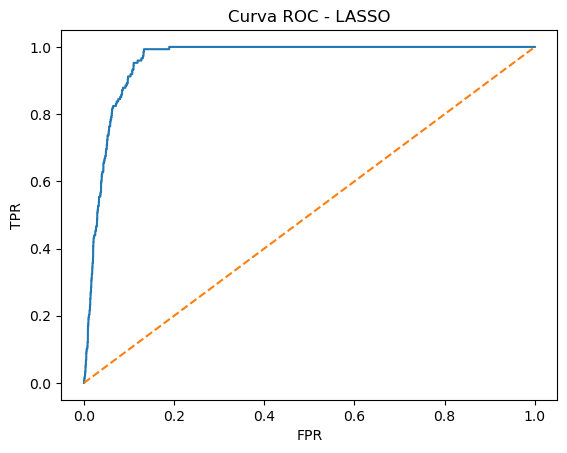

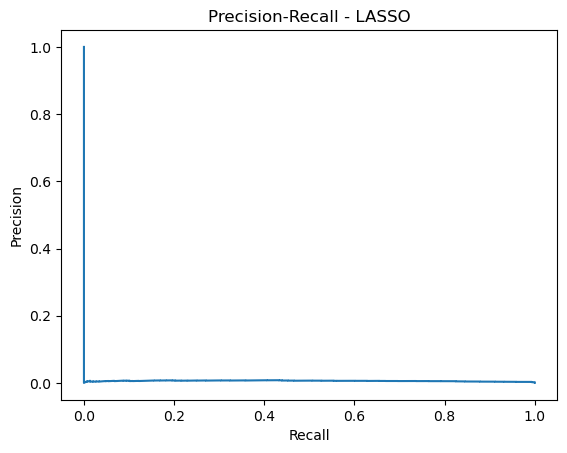

In [23]:
# ============================================================
# PASO 16 — CURVAS
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# ROC
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Curva ROC - LASSO")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

# Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.title("Precision-Recall - LASSO")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [24]:
# ============================================================
# PASO 18 — IMPORTANCIA DE VARIABLES SUBBAGGING 
# ============================================================

feature_names = preprocessor.get_feature_names_out()

coef = best_model.coef_[0]

feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coef
})

feature_importance["Importancia"] = np.abs(feature_importance["Coeficiente"])

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

print("\nTop variables LASSO:")
print(feature_importance.head(10))


Top variables LASSO:
                                         Variable  Coeficiente  Importancia
110              cat__DEPARTAMENTO CONTRATISTA_34    -8.840340     8.840340
42             cat__JUSTIFICACION DEL CONTRATO_20     5.553705     5.553705
40             cat__JUSTIFICACION DEL CONTRATO_15     3.329526     3.329526
43             cat__JUSTIFICACION DEL CONTRATO_21    -2.923260     2.923260
101            cat__TIPO DE EMPRESA CONTRATISTA_7    -1.979288     1.979288
73   cat__SECTOR ECONOMICO ENTIDAD CONTRATANTE_16     1.614763     1.614763
30               cat__MODALIDAD DE CONTRATACION_2    -1.193347     1.193347
38             cat__JUSTIFICACION DEL CONTRATO_12    -1.121621     1.121621
199                     num__MONTO TRANSFERENCIAS    -1.121384     1.121384
39             cat__JUSTIFICACION DEL CONTRATO_14    -1.007532     1.007532


In [25]:

active_vars = feature_importance[feature_importance["Coeficiente"] != 0]

print("\nNúmero de variables seleccionadas por LASSO:")
print(len(active_vars))


Número de variables seleccionadas por LASSO:
142


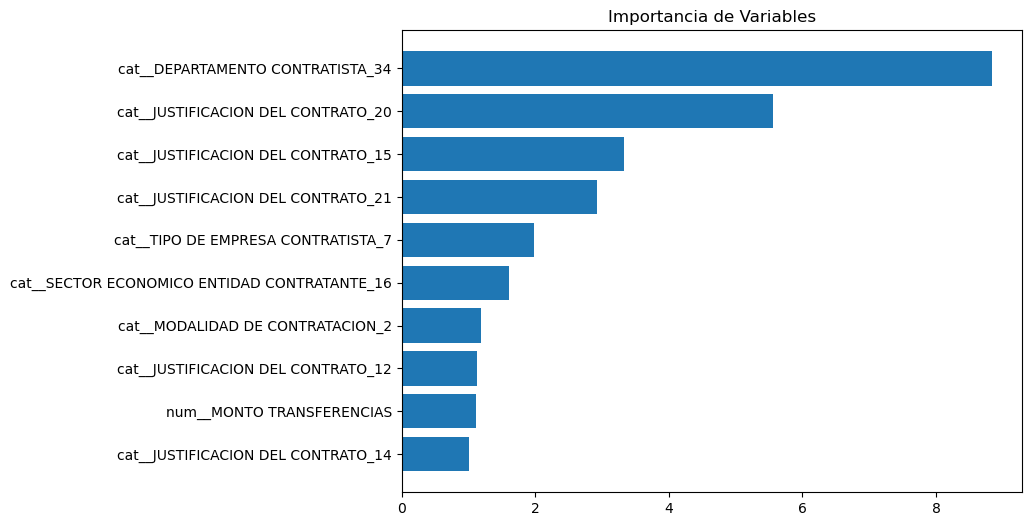

In [26]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Variable"], top_features["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables")
plt.show()

In [27]:
# ============================================================
# PASO 20 — ALERTAS
# ============================================================

alertas = pd.DataFrame({
    "Probabilidad": test_probs
})

alertas["Score"] = alertas["Probabilidad"] * 100

alertas["Nivel"] = pd.cut(
    alertas["Score"],
    bins=[0, 10, 30, 60, 100],
    labels=["Bajo", "Medio", "Alto", "Crítico"]
)

print("\nDistribución de alertas:")
print(alertas["Nivel"].value_counts())


Distribución de alertas:
Nivel
Bajo       341506
Medio       13050
Alto         7134
Crítico      4410
Name: count, dtype: int64


In [28]:
# ============================================================
# PASO 21 — IMPACTO ECONÓMICO
# ============================================================

if "VALOR CONTRATO" in X_test.columns:

    alertas["Valor_Contrato"] = pd.to_numeric(
        X_test["VALOR CONTRATO"], errors="coerce"
    )

    alertas["Perdida_Esperada"] = (
        alertas["Probabilidad"] * alertas["Valor_Contrato"]
    )

    print("\nTop contratos con mayor riesgo:")
    print(alertas.sort_values(
        by="Perdida_Esperada",
        ascending=False
    ).head(10))


Top contratos con mayor riesgo:
        Probabilidad      Score    Nivel  Valor_Contrato  Perdida_Esperada
257624      0.968440  96.843967  Crítico       27.074152         26.219682
233296      0.967872  96.787241  Crítico       27.035319         26.166739
221838      0.975947  97.594715  Crítico       26.279728         25.647626
52846       0.983886  98.388596  Crítico       25.130750         24.725793
99581       0.908959  90.895891  Crítico       27.197157         24.721098
1577        0.937993  93.799251  Crítico       26.155135         24.533321
228713      0.983563  98.356347  Crítico       24.889931         24.480827
42498       0.986930  98.693014  Crítico       24.751046         24.427554
86119       0.965058  96.505791  Crítico       24.827631         23.960102
328587      0.979335  97.933546  Crítico       24.385948         23.882024


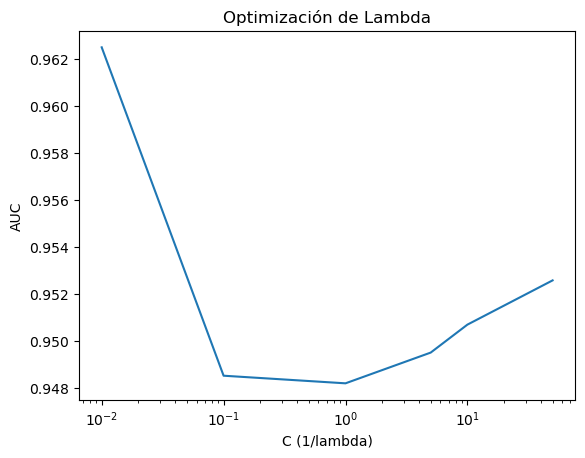

In [29]:
results_lambda = pd.DataFrame(grid.cv_results_)

plt.plot(results_lambda["param_C"], results_lambda["mean_test_score"])
plt.xscale("log")

plt.xlabel("C (1/lambda)")
plt.ylabel("AUC")
plt.title("Optimización de Lambda")

plt.show()

In [30]:
best_C = grid.best_params_["C"]
lambda_ = 1 / best_C

print("Lambda:", lambda_)

Lambda: 100.0
